In [135]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn
from scipy.stats import norm

In [136]:
def black_scholes(S, K, T=2, r=0.05, sigma=0.1, option_type='call'):
    """
    Calculates the theoretical price of a European option.
    
    Parameters:
    S : float : Current stock price
    K : float : Strike price
    T : float : Time to maturity (in years)
    r : float : Risk-free interest rate (annualized)
    sigma : float : Volatility of the underlying asset (annualized)
    option_type : str : 'call' or 'put'
    """
    # Handle the boundary condition at expiration
    if T <= 0:
        if option_type == 'call':
            return max(0.0, S - K)
        elif option_type == 'put':
            return max(0.0, K - S)
        else:
            raise ValueError("Invalid option_type. Use 'call' or 'put'.")

    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate the option price
    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("Invalid option_type. Use 'call' or 'put'.")
    hedge_weight=norm.cdf(d1)
    return price,hedge_weight

In [ ]:
def simulate_gbm(S0, mu, sigma, T, N, num_paths=10):
    """
    Simulates paths for a single asset following Geometric Brownian Motion.
    
    Parameters:
    - S0: Initial stock price
    - mu: Expected annual return (drift)
    - sigma: Annual volatility
    - T: Time horizon in years
    - N: Number of discrete time steps
    - num_paths: Number of simulated trajectories
    
    Returns:
    - t: 1D array of time steps
    - S: 2D array of simulated paths with shape (N+1, num_paths)
    """
    dt = T / N
    t = np.linspace(0, T, N + 1)
    
    # Generate independent standard normal random variables
    # Shape: (N, num_paths)
    Z = np.random.standard_normal((N, num_paths))
    
    # Compute the cumulative Brownian motion paths
    # Cumulative sum over time steps for each path
    W = np.vstack([np.zeros(num_paths), np.cumsum(Z * np.sqrt(dt), axis=0)])
    
    # Calculate the asset price paths using the analytical solution
    # Broadcast t[:, None] to match shape (N+1, num_paths)
    S = S0 * np.exp((mu - 0.5 * sigma**2) * t[:, None] + sigma * W)
    
    return t, S


In [138]:
t,S1=simulate_gbm(100,0.05,0.1,2,750,1000)
option1,weight1=black_scholes(100,100)
option1=option1+100

t,S2=simulate_gbm(150,-0.05,0.3,2,750,1000)
option2,weight2=black_scholes(150,150)
option2=option2+150

n = 100 

# 1. Single-share prices today
S1_0 = 100.0
S2_0 = 150.0

r=0.05
sigma=0.3
T=2
K=100
K1=0.5
K2=1-K1

percentage_margin=1
# 2. Get single-share simulated option prices (No 'n' multiplication here)


# 3. Define your Alpha hedge factors (1/weight)
alpha1 = 1 / weight1
alpha2 = 1 / weight2

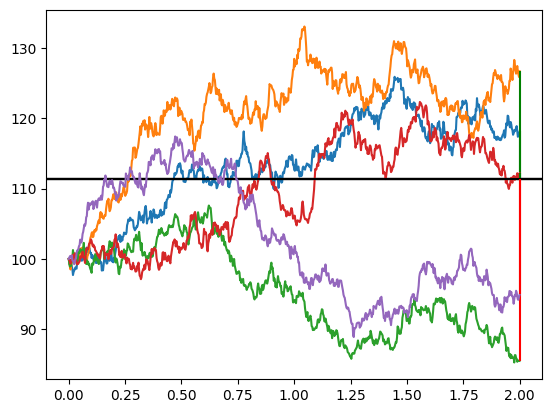

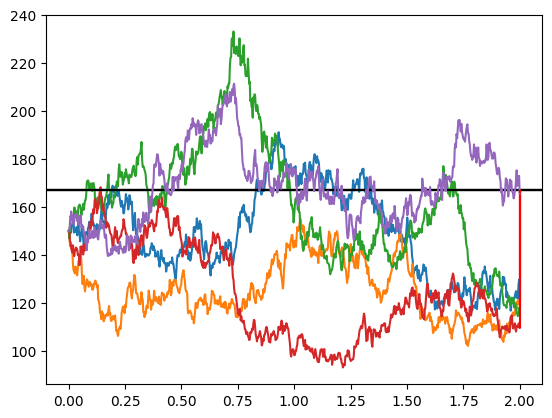

In [139]:
opt1_premium = np.exp(-r*T) * np.mean(np.maximum(S1[-1,:] - 100, 0))
opt2_premium = np.exp(-r*T) * np.mean(np.maximum(S2[-1,:] - 150, 0))
capital1 = (n * S1_0) + (alpha1 * n * opt1_premium)
capital2 = (n * S2_0) + (alpha2 * n * opt2_premium)
for x in range(5):

    plt.axhline(option1,color="black")
    plt.plot(t,S1[:,x])
    plt.vlines(t[-1],option1,S1[-1,x],color=("red" if option1>S1[-1,x] else "green"))
plt.show()

for x in range(5):
    plt.axhline(option2,color="black")
    plt.plot(t,S2[:,x])
    plt.vlines(t[-1],option2,S2[-1,x],color=("red" if option2>S2[-1,x] else "green"))
plt.show()

In [140]:
class PINN(nn.Module):
    """
    Generalized PINN: same PDE as the original model, but sigma and rho are now
    NETWORK INPUTS instead of fixed training-time constants. One trained model
    can be queried at any (t, y1, y2, sigma, rho) without retraining.

    Architecture follows the diagram: 5 -> 64 -> 128 -> 128 -> 64 -> 1
    """

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(5, 64),
            nn.Tanh(),
            nn.Linear(64, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, t, y1, y2, sigma, rho):
        # Each input is expected as shape (batch, 1). Concatenating along dim=1
        # (not stacking) gives the correct (batch, 5) network input.
        x = torch.stack([t, y1, y2, sigma, rho], dim=0).unsqueeze(0)
        return self.net(x)


    def set(self, t, y1, y2, sigma, rho):
        def col(x):
            return torch.as_tensor(x, dtype=torch.float32).reshape(-1, 1)

        t = torch.tensor(t, dtype=torch.float32, requires_grad=True)
        y1 = torch.tensor(y1, dtype=torch.float32, requires_grad=True)
        y2 = torch.tensor(y2, dtype=torch.float32, requires_grad=True)
        sigma = torch.tensor(sigma, dtype=torch.float32, requires_grad=True)
        rho = torch.tensor(rho, dtype=torch.float32, requires_grad=True)

        w1 = self.forward(t, y1, y2, sigma, rho)
        w2 = self.forward(t, y2, y1, sigma, rho)

        ones = torch.ones_like(w1)
        dw1 = torch.autograd.grad(w1, y1, grad_outputs=ones, create_graph=True, allow_unused=True)[0]
        dw2 = torch.autograd.grad(w1, y2, grad_outputs=ones, create_graph=True, allow_unused=True)[0]

        scalar_factor = 1.0 / (dw1 ** 2 - dw2 ** 2)
        row1 = torch.stack([dw1, -dw2])
        row2 = torch.stack([-dw2, dw1])
        matrix = torch.stack([row1, row2])
        A = scalar_factor * matrix

        return w1, w2, A

In [141]:
model=PINN()
model.load_state_dict(torch.load('model.pth', weights_only=True,map_location=torch.device('cpu')))
model.eval()

PINN(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [142]:
def compare_strats(toggle, min_capital_frac=0.05):
    """
    Per-simulation comparison of:
      - 'Original' strategy: independent single-asset BS delta-hedge for S1 and S2
      - 'My' strategy: PINN-based two-asset hedge (unchanged logic)

    Fixes vs. the previous version:
      1. Black-Scholes price & hedge weight are now recomputed EVERY trial using the
         SAME mu/sigma actually used to simulate the GBM path (previously weight1/weight2
         were computed once outside the loop using the function's default args,
         so the 'original' hedge ratio never matched the simulated volatility regime).
      2. Capital denominators are floored at a small fraction of notional
         (min_capital_frac * S0) before dividing, so a near-zero or sign-flipping
         denominator can no longer blow the percentage return up to +-1000s of percent.
         Trials that hit the floor are still counted, just not allowed to explode the scale.
    """
    # ---- simulate this trial's randomized regime ----
    mu1, sig1 = np.random.rand()*0.5, np.random.rand()*0.2
    mu2, sig2 = np.random.rand()*1-0.5, sig1
    rho=0.3

    t, S1 = simulate_gbm(100, mu1, sig1, 2, 750, 1000)
    t, S2 = simulate_gbm(150, mu2, sig2, 2, 750, 1000)

    n = 100
    S1_0, S2_0 = 100.0, 150.0
    r, T = 0.05, 2
    K1 = 0.5
    K2 = 1 - K1
    percentage_margin = 1

    # ---- recompute BS price & hedge weight PER TRIAL using actual sig1/sig2 ----
    # (this is the key fix: previously these used stale default-arg values)
    option1, weight1 = black_scholes(S1_0, 100, T=T, r=r, sigma=sig1)
    option2, weight2 = black_scholes(S2_0, 150, T=T, r=r, sigma=sig2)
    option1 = option1 + S1_0
    option2 = option2 + S2_0

    alpha1 = 1 / weight1
    alpha2 = 1 / weight2

    # ---- Monte Carlo option premiums from the simulated terminal distribution ----
    opt1_premium = np.exp(-r * T) * np.mean(np.maximum(S1[-1, :] - 100, 0))
    opt2_premium = np.exp(-r * T) * np.mean(np.maximum(S2[-1, :] - 150, 0))

    # ---- guarded capital helper (fix for the divide-by-near-zero blowups) ----
    def safe_capital(raw_capital, notional):
        floor = min_capital_frac * notional
        if raw_capital >= 0:
            return max(raw_capital, floor)
        else:
            return min(raw_capital, -floor)

    # ---- ORIGINAL strategy: independent single-asset delta hedge ----
    if option1 > opt1_premium:
        capital1 = alpha1 * opt1_premium + percentage_margin * S1_0
        payoff1 = (alpha1 * np.mean(np.maximum(S1[-1, :] - 100, 0))
                   + S1_0 - np.mean(S1[-1, :]) + percentage_margin * S1_0)
    else:
        capital1 = alpha1 * (S1_0 - opt1_premium) + S1_0
        payoff1 = (-1 * alpha1 * np.mean(np.maximum(S1[-1, :] - 100, 0))
                   + np.mean(S1[-1, :]) * (alpha1 + 1))
    capital1 = safe_capital(capital1, S1_0)

    if option2 > opt2_premium:
        capital2 = alpha2 * opt2_premium + percentage_margin * S2_0
        payoff2 = (alpha2 * np.mean(np.maximum(S2[-1, :] - 150, 0))
                   + S2_0 - np.mean(S2[-1, :]) + percentage_margin * S2_0)
    else:
        capital2 = alpha2 * (S2_0 - opt2_premium) + S2_0
        payoff2 = (-1 * alpha2 * np.mean(np.maximum(S2[-1, :] - 150, 0))
                   + np.mean(S2[-1, :]) * (alpha2 + 1))
    capital2 = safe_capital(capital2, S2_0)

    profit1 = (payoff1 - capital1) / capital1
    profit2 = (payoff2 - capital2) / capital2
    total_return_percentage = (K1 * profit1 + K2 * profit2) * 100

    # ---- MY strategy: PINN-based two-asset hedge (unchanged) ----
    y1, y2 = 100, 150

    with torch.enable_grad():
        price1, price2, W = model.set(T, y1, y2,sig1,rho)

    price1 = price1.detach().numpy()[0][0]
    price2 = price2.detach().numpy()[0][0]
    W = W.detach().numpy()

    K = np.array([K1, K2]).T
    Capital = np.array([[0.0], [0.0]])
    Payoff = np.array([[0.0], [0.0]])

    Alpha = np.reshape((K.T @ W), (2, 1))

    if opt1_premium > price1:
        Capital[0][0] = Alpha[0][0] * (y1 - opt1_premium) + K1 * y1
        Payoff[0][0] = ((Alpha[0][0] + K1) * np.mean(S1[-1, :])
                         - Alpha[0][0] * np.mean(np.maximum(S1[-1, :], 100)))
    else:
        Capital[0][0] = Alpha[0][0] * opt1_premium + percentage_margin * K1 * y1
        Payoff[0][0] = (K1 * (y1 - np.mean(S1[-1, :])) + percentage_margin * K1 * y1
                         + Alpha[0][0] * np.mean(np.maximum(S1[-1, :] - 100, 0)))

    if opt2_premium > price2:
        Capital[1][0] = Alpha[1][0] * (y2 - opt2_premium) + K2 * y2
        Payoff[1][0] = ((Alpha[1][0] + K2) * np.mean(S2[-1, :])
                         - Alpha[1][0] * np.mean(np.maximum(S2[-1, :], 150)))
    else:
        Capital[1][0] = Alpha[1][0] * opt2_premium + percentage_margin * K2 * y2
        Payoff[1][0] = (K2 * (y2 - np.mean(S2[-1, :])) + percentage_margin * K2 * y2
                         + Alpha[1][0] * np.mean(np.maximum(S2[-1, :] - 150, 0)))

    # same min_capital_frac guard applied to the combined PINN capital
    total_capital = Capital[0][0] + Capital[1][0]
    total_capital = safe_capital(total_capital, S1_0 + S2_0)

    f = np.ones_like(Payoff)
    Profit = (((f.T @ Payoff)[0][0] - total_capital) / total_capital) * 100

    if toggle == 0:
        print(f"Returns in my strategy  are: {Profit:.2f}%")
        print(f"Returns in strategy other are: {total_return_percentage:.2f}%")

    return Profit, total_return_percentage

In [143]:
Trials=10000
My_strat=[]
Original_Strat=[]
for x in range(Trials):
    x,y=compare_strats(x%1000)
    My_strat.append(x)
    Original_Strat.append(y)
My_strat=np.array(My_strat)
Original_Strat=np.array(Original_Strat)

Returns in my strategy  are: 146.33%
Returns in strategy other are: 287.94%
Returns in my strategy  are: 14.03%
Returns in strategy other are: 10.87%
Returns in my strategy  are: -20.30%
Returns in strategy other are: -15.52%
Returns in my strategy  are: 111.74%
Returns in strategy other are: 228.63%
Returns in my strategy  are: 3.25%
Returns in strategy other are: -27.19%
Returns in my strategy  are: 35.78%
Returns in strategy other are: 15.30%
Returns in my strategy  are: 202.61%
Returns in strategy other are: 508.04%
Returns in my strategy  are: 144.47%
Returns in strategy other are: 393.38%
Returns in my strategy  are: -24.18%
Returns in strategy other are: -14.41%
Returns in my strategy  are: 14.42%
Returns in strategy other are: 12.32%


/tmp/ipykernel_8386/4220206241.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


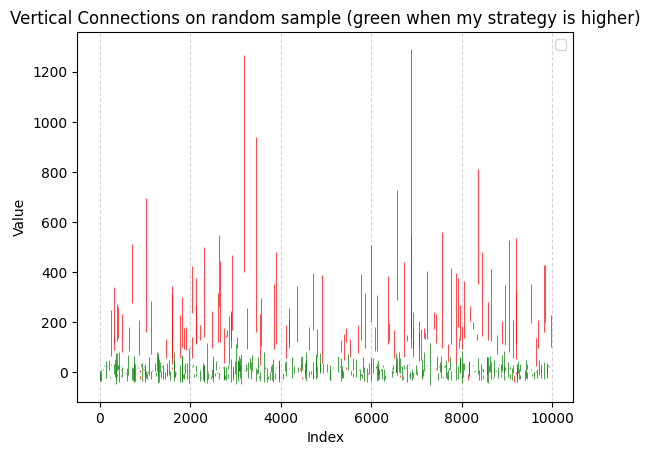

In [144]:
X=np.arange(len(My_strat))
sample = np.random.choice(X, size=500, replace=False)
colors = np.where(My_strat[sample] >= Original_Strat[sample], "green", "red")
plt.vlines(sample, ymin=Original_Strat[sample], ymax=My_strat[sample], colors=colors, linewidth=0.5, zorder=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Vertical Connections on random sample (green when my strategy is higher)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

/tmp/ipykernel_8386/991829927.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


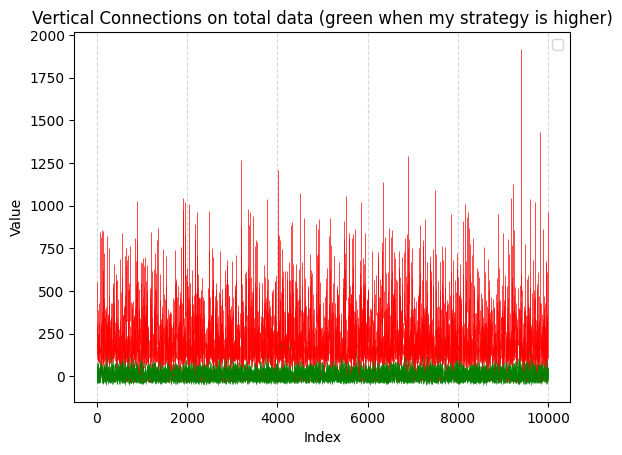

In [145]:
X=np.arange(len(My_strat))
sample = X
colors = np.where(My_strat[sample] >= Original_Strat[sample], "green", "red")
plt.vlines(sample, ymin=Original_Strat[sample], ymax=My_strat[sample], colors=colors, linewidth=0.5, zorder=2)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Vertical Connections on total data (green when my strategy is higher)")
plt.legend()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

Percentage wins:  0.5649


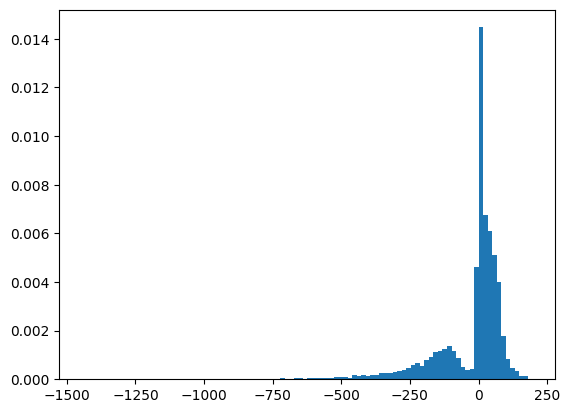

Sigmoid mean: 0.647251630952693
Sharpe of my strat= 0.859333227773276
Sharpe of original strat= 0.4575840899146476


/tmp/ipykernel_8386/3278568868.py:5: RuntimeWarning: overflow encountered in exp
  print("Sigmoid mean:",np.mean(1/(1+np.exp(-My_strat+Original_Strat))))


In [147]:
indicator=np.where((My_strat-Original_Strat)>3,1,0)
print("Percentage wins: ",np.mean(indicator))
plt.hist((My_strat-Original_Strat),density=True,bins=100)
plt.show()
print("Sigmoid mean:",np.mean(1/(1+np.exp(-My_strat+Original_Strat))))
print("Sharpe of my strat=",np.mean(My_strat)/np.std(My_strat))
print("Sharpe of original strat=",np.mean(Original_Strat)/np.std(Original_Strat))